# AED POI Candidate and Deployment Policy Analysis

This notebook summarizes Yixing AED candidate POIs and sample 1 deployment results. It is designed for policy review: which building or public-service types are available as candidates, which types receive high model-derived scores, and which types are selected by the final deployment optimizer.

In [10]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid")


def find_project_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "notebooks" / "Optimizor").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing data/ and notebooks/Optimizor/.")


PROJECT_ROOT = find_project_root()
OPTIMIZOR_DIR = PROJECT_ROOT / "notebooks" / "Optimizor"
OUTPUT_DIR = OPTIMIZOR_DIR / "outputs"
RUNS_DIR = OUTPUT_DIR / "runs"
TOTAL_SCORE_PATH = OUTPUT_DIR / "total_score.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Candidate score table: {TOTAL_SCORE_PATH}")
print(f"Optimizer runs: {RUNS_DIR}")

Project root: C:\Users\Yuan\Desktop\YUAN\OHCA 宜興市\Yi-xing-city-OHCA-loctaion-prediction
Candidate score table: C:\Users\Yuan\Desktop\YUAN\OHCA 宜興市\Yi-xing-city-OHCA-loctaion-prediction\notebooks\Optimizor\outputs\total_score.csv
Optimizer runs: C:\Users\Yuan\Desktop\YUAN\OHCA 宜興市\Yi-xing-city-OHCA-loctaion-prediction\notebooks\Optimizor\outputs\runs


## Load Candidate and Deployment Data

The candidate table contains all whitelist POIs after cleaning and score calculation. The deployment table below concatenates sample 1 selected locations from every sampled optimizer run and model.

In [11]:
MODEL_ORDER = ["xgb", "mlp", "svr"]
MODEL_LABELS = {"xgb": "XGB", "mlp": "MLP", "svr": "SVR"}
SCORE_COLS = {
    "xgb": "total_score_xgb",
    "mlp": "total_score_mlp",
    "svr": "total_score_svr",
}
RANK_COLS = {
    "xgb": "score_rank_xgb",
    "mlp": "score_rank_mlp",
    "svr": "score_rank_svr",
}
MODEL_COLORS = {
    "xgb": "#d62728",
    "mlp": "#2ca02c",
    "svr": "#8c564b",
}

POI_GROUPS = {
    "healthcare": ["hospital", "clinic", "pharmacy", "dentist"],
    "education": ["school", "kindergarten", "university", "college", "training", "library"],
    "transportation": ["bus_station", "parking", "charging_station", "fuel"],
    "public_services": ["bank", "post_office"],
    "culture_recreation_public": ["public", "sports_centre", "cinema", "theatre", "arts_centre", "exhibition_centre"],
}
TAG_TO_GROUP = {tag: group for group, tags in POI_GROUPS.items() for tag in tags}


def parse_run_parameters(run_name: str) -> dict[str, object]:
    pattern = re.compile(
        r"sampled_(?P<sample_size>\d+)x(?P<sample_count>\d+)_seed(?P<seed>\d+)_d(?P<distance_m>\d+)m_loc(?P<loc_num>\d+)"
    )
    match = pattern.fullmatch(str(run_name))
    if not match:
        return {}
    return {key: int(value) for key, value in match.groupdict().items()}


def resolve_output_path(path_text: str, run_name: str) -> Path:
    path = Path(str(path_text))
    if path.exists():
        return path
    local_path = RUNS_DIR / run_name / "selected" / path.name
    if local_path.exists():
        return local_path
    raise FileNotFoundError(f"Selected output path not found: {path_text}")


def add_poi_group(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["osm_tag"] = out["osm_tag"].fillna("unknown").astype(str)
    out["poi_group"] = out["osm_tag"].map(TAG_TO_GROUP).fillna("other")
    if "銵?憭抒掩" in out.columns:
        out["industry_major"] = out["銵?憭抒掩"].fillna("unknown").astype(str)
    else:
        out["industry_major"] = "unknown"
    if "銵?銝剔掩" in out.columns:
        out["industry_middle"] = out["銵?銝剔掩"].fillna("unknown").astype(str)
    else:
        out["industry_middle"] = "unknown"
    return out


candidates = pd.read_csv(TOTAL_SCORE_PATH)
candidates = add_poi_group(candidates)
for col in list(SCORE_COLS.values()) + list(RANK_COLS.values()):
    candidates[col] = pd.to_numeric(candidates[col], errors="coerce")

summary_paths = sorted(RUNS_DIR.glob("sampled_*_loc*/yixing_sampled_optimization_summary.csv"))
if not summary_paths:
    raise FileNotFoundError(f"No sampled optimization summary files found under {RUNS_DIR}")

summary_frames = []
for summary_path in summary_paths:
    frame = pd.read_csv(summary_path)
    frame["run_name"] = summary_path.parent.name
    for key, value in parse_run_parameters(summary_path.parent.name).items():
        if key not in frame.columns:
            frame[key] = value
    summary_frames.append(frame)

run_summary = pd.concat(summary_frames, ignore_index=True)
sample1_summary = run_summary[(run_summary["sample_id"] == 1) & (run_summary["model"].isin(MODEL_ORDER))].copy()
sample1_summary["model"] = pd.Categorical(sample1_summary["model"], MODEL_ORDER, ordered=True)
sample1_summary = sample1_summary.sort_values(["model", "sample_size", "distance_m", "run_name"]).reset_index(drop=True)

selected_frames = []
for row in sample1_summary.itertuples(index=False):
    selected_path = resolve_output_path(row.output_path, row.run_name)
    selected = pd.read_csv(selected_path)
    selected = add_poi_group(selected)
    selected["model"] = str(row.model)
    selected["run_name"] = row.run_name
    selected["sample_size"] = int(row.sample_size)
    selected["distance_m"] = int(row.distance_m)
    selected["loc_num"] = int(row.loc_num)
    selected["objective_value"] = float(row.objective_value)
    selected["selected_path"] = str(selected_path)
    selected_frames.append(selected)

deployments = pd.concat(selected_frames, ignore_index=True)
for col in list(SCORE_COLS.values()) + list(RANK_COLS.values()):
    deployments[col] = pd.to_numeric(deployments[col], errors="coerce")

print(f"Candidate POIs: {len(candidates):,}")
print(f"Sample 1 deployment rows across all runs/models: {len(deployments):,}")
print(f"Sample 1 run/model combinations: {sample1_summary.shape[0]:,}")

display(sample1_summary[["run_name", "model", "sample_size", "distance_m", "loc_num", "selected_count", "objective_value"]])

Candidate POIs: 7,956
Sample 1 deployment rows across all runs/models: 78,000
Sample 1 run/model combinations: 60


,run_name,model,sample_size,distance_m,loc_num,selected_count,objective_value
0,sampled_3000x10_seed2770_d100m_loc1300,xgb,3000,100,1300,1300,1242.619010
1,sampled_3000x10_seed2770_d150m_loc1300,xgb,3000,150,1300,1300,916.933701
2,sampled_3000x10_seed2770_d200m_loc1300,xgb,3000,200,1300,1300,674.793416
3,sampled_3000x10_seed2770_d250m_loc1300,xgb,3000,250,1300,1300,485.230156
4,sampled_4000x10_seed2770_d50m_loc1300,xgb,4000,50,1300,1300,1905.347060
5,sampled_4000x10_seed2770_d100m_loc1300,xgb,4000,100,1300,1300,1457.861612
6,sampled_4000x10_seed2770_d150m_loc1300,xgb,4000,150,1300,1300,1067.234922
7,sampled_4000x10_seed2770_d200m_loc1300,xgb,4000,200,1300,1300,820.974146
8,sampled_4000x10_seed2770_d250m_loc1300,xgb,4000,250,1300,1300,635.138926
9,sampled_4000x10_seed2770_d300m_loc1300,xgb,4000,300,1300,1300,467.124546


## Candidate POI Availability

These tables show the candidate pool available to policymakers before optimization. `poi_group` follows the whitelist groups used by the optimizer; `osm_tag` is the more detailed building or public-service type.

Candidate count by policy group


,poi_group,count,share
4,transportation,3886,0.488436
2,healthcare,1986,0.249623
1,education,920,0.115636
0,culture_recreation_public,696,0.087481
3,public_services,468,0.058824


Candidate count by detailed POI type


,poi_group,osm_tag,count,share
18,transportation,bus_station,1963,0.505147
21,transportation,parking,1545,0.397581
15,healthcare,pharmacy,871,0.438570
12,healthcare,clinic,851,0.428499
10,education,training,594,0.645652
4,culture_recreation_public,sports_centre,455,0.653736
16,public_services,bank,430,0.918803
19,transportation,charging_station,285,0.073340
9,education,school,156,0.169565
14,healthcare,hospital,136,0.068479


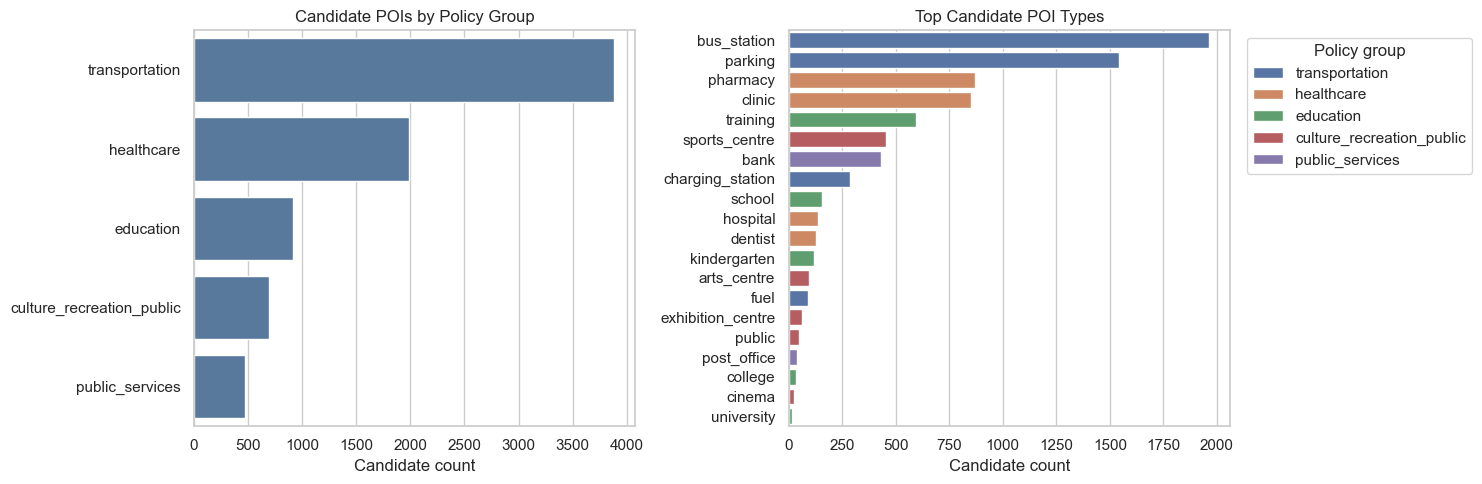

In [12]:
def count_share(df: pd.DataFrame, group_cols: list[str], count_name="count") -> pd.DataFrame:
    out = df.groupby(group_cols, dropna=False).size().reset_index(name=count_name)
    total_cols = group_cols[:-1]
    if total_cols:
        out["share"] = out[count_name] / out.groupby(total_cols)[count_name].transform("sum")
    else:
        out["share"] = out[count_name] / out[count_name].sum()
    return out.sort_values(count_name, ascending=False)


candidate_group_counts = count_share(candidates, ["poi_group"])
candidate_tag_counts = count_share(candidates, ["poi_group", "osm_tag"])

print("Candidate count by policy group")
display(candidate_group_counts)

print("Candidate count by detailed POI type")
display(candidate_tag_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=candidate_group_counts, x="count", y="poi_group", color="#4c78a8", ax=axes[0])
axes[0].set_title("Candidate POIs by Policy Group")
axes[0].set_xlabel("Candidate count")
axes[0].set_ylabel("")

top_tags = candidate_tag_counts.head(20)
sns.barplot(data=top_tags, x="count", y="osm_tag", hue="poi_group", dodge=False, ax=axes[1])
axes[1].set_title("Top Candidate POI Types")
axes[1].set_xlabel("Candidate count")
axes[1].set_ylabel("")
axes[1].legend(title="Policy group", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Candidate Score and SHAP-Derived Priority

The optimizer score columns are SHAP-derived model scores for candidate suitability. Higher scores indicate stronger priority for that model. The table summarizes score level and top-decile presence by POI group.

Candidate score summary by model and policy group


,model,model_label,poi_group,candidate_count,mean_score,median_score,p90_score,max_score,top_decile_candidates,top_decile_share_within_group
4,mlp,MLP,transportation,3886,-5.725054,-0.888214,2.385709,22.049627,358,0.092126
2,mlp,MLP,healthcare,1986,-6.960172,-3.264498,2.774714,19.959644,203,0.102216
0,mlp,MLP,culture_recreation_public,696,-7.531934,-1.840860,4.014654,24.429264,102,0.146552
1,mlp,MLP,education,920,-9.818839,-4.901393,2.863628,21.917993,97,0.105435
3,mlp,MLP,public_services,468,-10.522924,-5.518001,2.056130,18.348235,36,0.076923
7,svr,SVR,healthcare,1986,10.381726,6.385624,31.390545,61.153360,281,0.141490
6,svr,SVR,education,920,7.479154,4.968985,28.419048,66.067431,107,0.116304
8,svr,SVR,public_services,468,6.232041,4.293279,27.184406,59.868093,51,0.108974
5,svr,SVR,culture_recreation_public,696,5.318579,2.270111,27.631711,60.015135,74,0.106322
9,svr,SVR,transportation,3886,5.118944,0.681484,23.542300,59.388916,283,0.072826


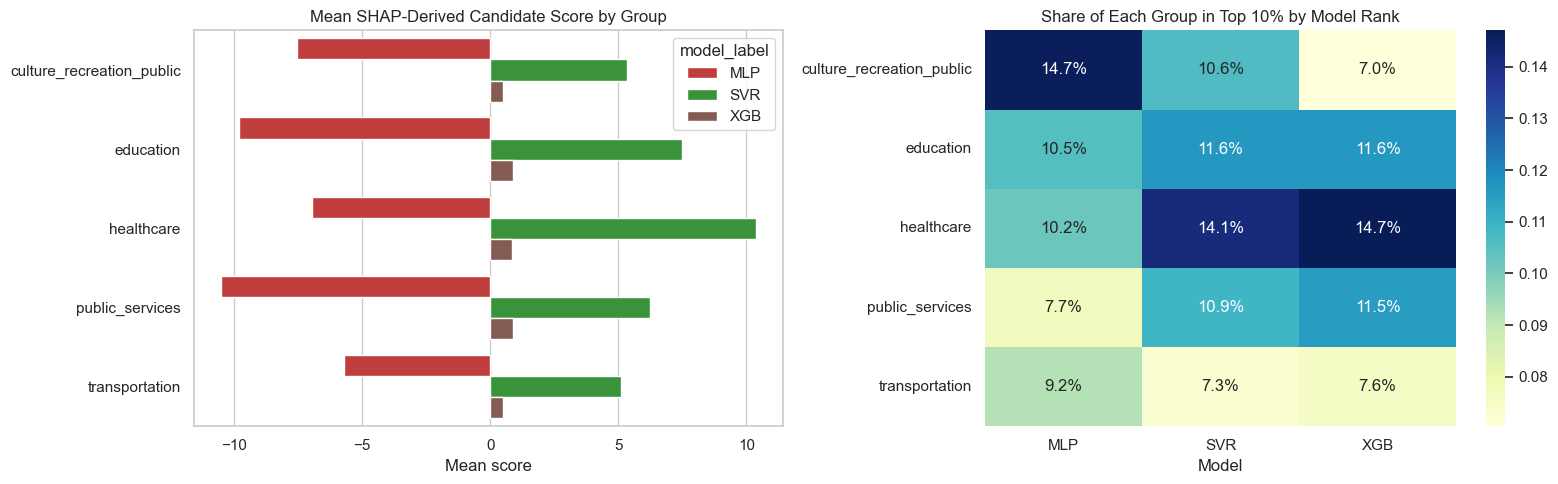

In [13]:
score_frames = []
for model, score_col in SCORE_COLS.items():
    rank_col = RANK_COLS[model]
    frame = candidates[["candidate_id", "name", "poi_group", "osm_tag", "industry_major", score_col, rank_col]].copy()
    frame = frame.rename(columns={score_col: "score", rank_col: "score_rank"})
    frame["model"] = model
    score_frames.append(frame)

candidate_scores = pd.concat(score_frames, ignore_index=True)
candidate_scores["model_label"] = candidate_scores["model"].map(MODEL_LABELS)
candidate_scores["top_decile_by_rank"] = candidate_scores["score_rank"] <= np.ceil(len(candidates) * 0.10)

candidate_group_scores = (
    candidate_scores.groupby(["model", "model_label", "poi_group"], observed=True)
    .agg(
        candidate_count=("candidate_id", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        max_score=("score", "max"),
        top_decile_candidates=("top_decile_by_rank", "sum"),
    )
    .reset_index()
)
candidate_group_scores["top_decile_share_within_group"] = (
    candidate_group_scores["top_decile_candidates"] / candidate_group_scores["candidate_count"]
)

print("Candidate score summary by model and policy group")
display(candidate_group_scores.sort_values(["model", "mean_score"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(
    data=candidate_group_scores,
    x="mean_score",
    y="poi_group",
    hue="model_label",
    palette=[MODEL_COLORS[m] for m in MODEL_ORDER],
    ax=axes[0],
)
axes[0].set_title("Mean SHAP-Derived Candidate Score by Group")
axes[0].set_xlabel("Mean score")
axes[0].set_ylabel("")

heat = candidate_group_scores.pivot(index="poi_group", columns="model_label", values="top_decile_share_within_group")
sns.heatmap(heat, annot=True, fmt=".1%", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Share of Each Group in Top 10% by Model Rank")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## High-Priority POI Types

This section highlights detailed POI types that are both available and high-scoring. It helps identify which building types are strong candidates before any final deployment constraints are applied.

### XGB high-priority POI types

,model,model_label,poi_group,osm_tag,candidate_count,mean_score,median_score,max_score,top_decile_candidates,top_decile_share_within_type
65,xgb,XGB,transportation,parking,1545,0.808512,0.957873,3.455803,203,0.131392
59,xgb,XGB,healthcare,pharmacy,871,0.943159,0.994077,3.348247,145,0.166475
56,xgb,XGB,healthcare,clinic,851,0.796503,0.809800,3.420779,119,0.139835
54,xgb,XGB,education,training,594,1.011796,1.072568,3.381236,78,0.131313
62,xgb,XGB,transportation,bus_station,1963,0.192870,0.000000,3.325934,59,0.030056
60,xgb,XGB,public_services,bank,430,0.934683,0.953299,3.460570,51,0.118605
63,xgb,XGB,transportation,charging_station,285,0.804161,0.804355,3.404881,29,0.101754
48,xgb,XGB,culture_recreation_public,sports_centre,455,0.484533,0.259334,3.146967,28,0.061538
57,xgb,XGB,healthcare,dentist,128,0.813745,0.825675,2.985427,15,0.117188
58,xgb,XGB,healthcare,hospital,136,0.623176,0.646218,2.875990,13,0.095588


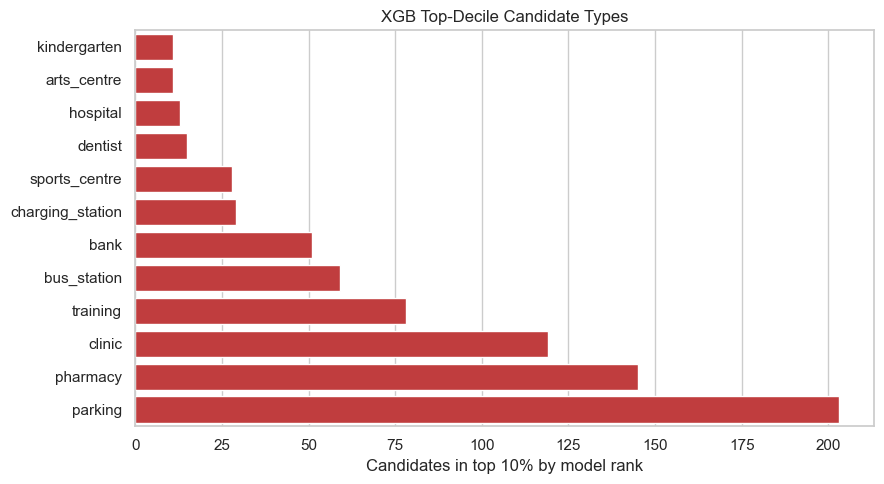

### MLP high-priority POI types

,model,model_label,poi_group,osm_tag,candidate_count,mean_score,median_score,max_score,top_decile_candidates,top_decile_share_within_type
18,mlp,MLP,transportation,bus_station,1963,-2.422197,-0.072857,19.677190,171,0.087112
21,mlp,MLP,transportation,parking,1545,-9.184935,-5.073299,22.049627,146,0.094498
15,mlp,MLP,healthcare,pharmacy,871,-7.211880,-4.419716,19.959644,96,0.110218
12,mlp,MLP,healthcare,clinic,851,-6.814300,-2.512179,18.893224,78,0.091657
10,mlp,MLP,education,training,594,-11.938376,-7.327272,19.147601,66,0.111111
2,mlp,MLP,culture_recreation_public,exhibition_centre,64,2.980965,3.201314,24.429264,36,0.562500
4,mlp,MLP,culture_recreation_public,sports_centre,455,-9.591572,-3.502243,16.497741,33,0.072527
16,mlp,MLP,public_services,bank,430,-10.937632,-5.783415,18.348235,32,0.074419
19,mlp,MLP,transportation,charging_station,285,-11.256444,-6.251465,17.648608,27,0.094737
0,mlp,MLP,culture_recreation_public,arts_centre,95,-4.166070,-0.258754,18.103423,25,0.263158


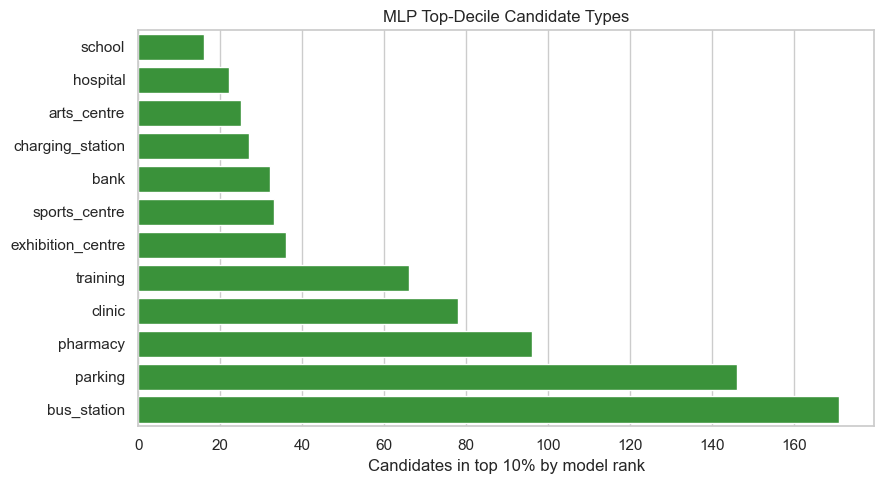

### SVR high-priority POI types

,model,model_label,poi_group,osm_tag,candidate_count,mean_score,median_score,max_score,top_decile_candidates,top_decile_share_within_type
43,svr,SVR,transportation,parking,1545,7.739718,3.746096,59.388414,173,0.111974
37,svr,SVR,healthcare,pharmacy,871,11.301758,7.786483,58.539145,134,0.153846
34,svr,SVR,healthcare,clinic,851,9.962136,5.505008,61.153360,120,0.141011
32,svr,SVR,education,training,594,7.572023,6.596868,59.491454,84,0.141414
40,svr,SVR,transportation,bus_station,1963,3.204287,0.029039,59.159213,77,0.039226
38,svr,SVR,public_services,bank,430,6.298832,4.792761,59.868093,47,0.109302
41,svr,SVR,transportation,charging_station,285,4.500823,3.450842,57.501568,30,0.105263
26,svr,SVR,culture_recreation_public,sports_centre,455,1.801941,0.721685,60.015135,25,0.054945
22,svr,SVR,culture_recreation_public,arts_centre,95,11.771552,9.561361,53.408351,21,0.221053
24,svr,SVR,culture_recreation_public,exhibition_centre,64,19.532146,15.056944,59.144547,18,0.281250


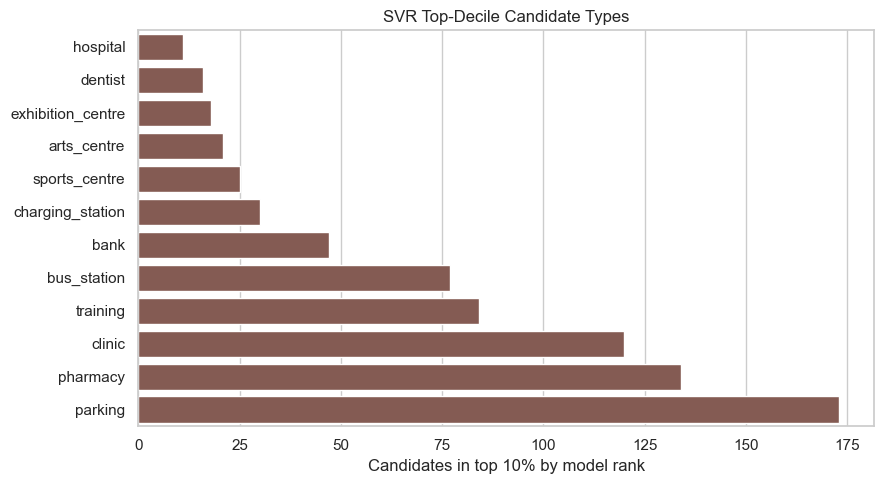

In [14]:
tag_score_summary = (
    candidate_scores.groupby(["model", "model_label", "poi_group", "osm_tag"], observed=True)
    .agg(
        candidate_count=("candidate_id", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        max_score=("score", "max"),
        top_decile_candidates=("top_decile_by_rank", "sum"),
    )
    .reset_index()
)
tag_score_summary["top_decile_share_within_type"] = tag_score_summary["top_decile_candidates"] / tag_score_summary["candidate_count"]

for model in MODEL_ORDER:
    model_table = tag_score_summary[tag_score_summary["model"] == model].copy()
    model_table = model_table.sort_values(["top_decile_candidates", "mean_score", "candidate_count"], ascending=False)
    display(Markdown(f"### {MODEL_LABELS[model]} high-priority POI types"))
    display(model_table.head(15))

    fig, ax = plt.subplots(figsize=(9, 5))
    top_plot = model_table.head(12).sort_values("top_decile_candidates")
    sns.barplot(data=top_plot, x="top_decile_candidates", y="osm_tag", color=MODEL_COLORS[model], ax=ax)
    ax.set_title(f"{MODEL_LABELS[model]} Top-Decile Candidate Types")
    ax.set_xlabel("Candidates in top 10% by model rank")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Deployment POI Type Statistics

The deployment results below use sample 1 from every optimizer parameter run. Counts are selected-location appearances across experiments. Unique candidate counts are also included to avoid over-reading repeated selections across parameter settings.

In [15]:
deployment_group_counts = (
    deployments.groupby(["model", "sample_size", "distance_m", "poi_group"], observed=True)
    .agg(
        selected_appearances=("candidate_id", "count"),
        unique_candidates=("candidate_id", "nunique"),
    )
    .reset_index()
)
deployment_group_counts["share_in_run"] = deployment_group_counts["selected_appearances"] / deployment_group_counts.groupby(
    ["model", "sample_size", "distance_m"]
)["selected_appearances"].transform("sum")

print("Deployment group counts by model, sample size, and distance")
display(deployment_group_counts.sort_values(["model", "sample_size", "distance_m", "selected_appearances"], ascending=[True, True, True, False]))

deployment_tag_counts = (
    deployments.groupby(["model", "poi_group", "osm_tag"], observed=True)
    .agg(
        selected_appearances=("candidate_id", "count"),
        unique_candidates=("candidate_id", "nunique"),
    )
    .reset_index()
    .sort_values(["model", "selected_appearances"], ascending=[True, False])
)

for model in MODEL_ORDER:
    display(Markdown(f"### {MODEL_LABELS[model]} deployed POI types across sample 1 runs"))
    display(deployment_tag_counts[deployment_tag_counts["model"] == model].head(20))

Deployment group counts by model, sample size, and distance


,model,sample_size,distance_m,poi_group,selected_appearances,unique_candidates,share_in_run
4,mlp,3000,100,transportation,787,787,0.605385
2,mlp,3000,100,healthcare,255,255,0.196154
1,mlp,3000,100,education,113,113,0.086923
0,mlp,3000,100,culture_recreation_public,108,108,0.083077
3,mlp,3000,100,public_services,37,37,0.028462
...,...,...,...,...,...,...,...
299,xgb,7000,300,transportation,840,840,0.646154
297,xgb,7000,300,healthcare,193,193,0.148462
296,xgb,7000,300,education,130,130,0.100000
295,xgb,7000,300,culture_recreation_public,107,107,0.082308


### XGB deployed POI types across sample 1 runs

,model,poi_group,osm_tag,selected_appearances,unique_candidates
62,xgb,transportation,bus_station,8620,1550
65,xgb,transportation,parking,4562,1112
56,xgb,healthcare,clinic,2373,595
59,xgb,healthcare,pharmacy,2050,551
54,xgb,education,training,1637,423
48,xgb,culture_recreation_public,sports_centre,1459,324
60,xgb,public_services,bank,974,299
63,xgb,transportation,charging_station,870,209
53,xgb,education,school,761,121
51,xgb,education,kindergarten,552,98


### MLP deployed POI types across sample 1 runs

,model,poi_group,osm_tag,selected_appearances,unique_candidates
18,mlp,transportation,bus_station,12176,1529
21,mlp,transportation,parking,3905,715
12,mlp,healthcare,clinic,2248,429
4,mlp,culture_recreation_public,sports_centre,1448,222
15,mlp,healthcare,pharmacy,1248,348
10,mlp,education,training,862,223
9,mlp,education,school,708,115
16,mlp,public_services,bank,555,150
19,mlp,transportation,charging_station,505,125
20,mlp,transportation,fuel,442,74


### SVR deployed POI types across sample 1 runs

,model,poi_group,osm_tag,selected_appearances,unique_candidates
40,svr,transportation,bus_station,9254,1541
43,svr,transportation,parking,4488,985
34,svr,healthcare,clinic,2370,558
37,svr,healthcare,pharmacy,2001,539
32,svr,education,training,1398,337
26,svr,culture_recreation_public,sports_centre,1344,268
38,svr,public_services,bank,837,243
31,svr,education,school,777,135
41,svr,transportation,charging_station,713,159
36,svr,healthcare,hospital,500,94


### XGB deployment composition, sample size 3000

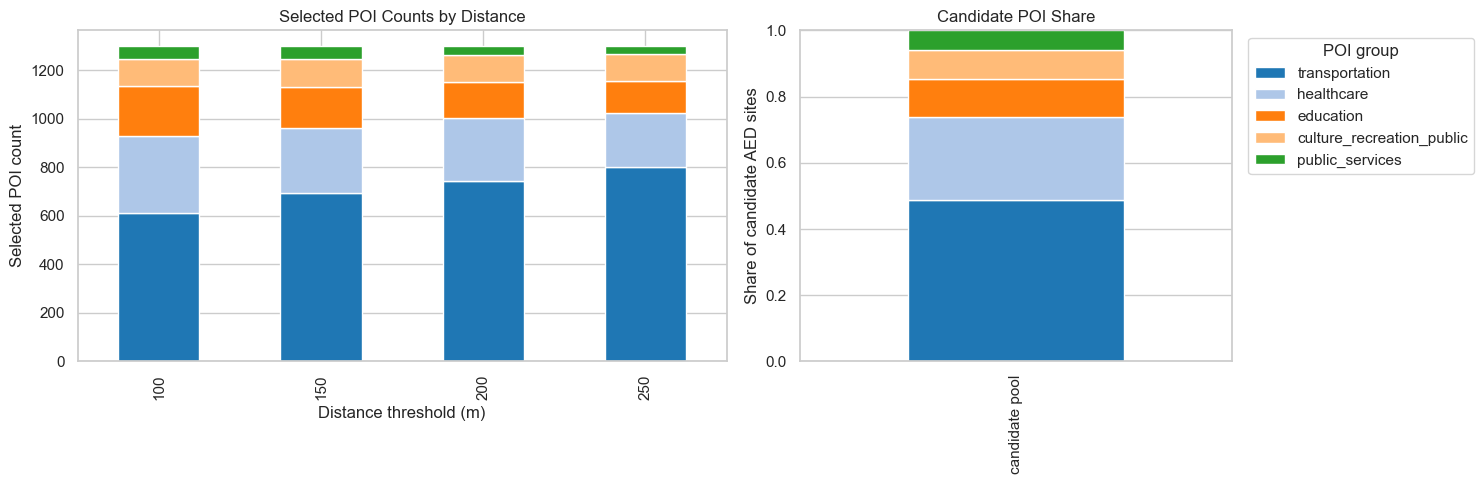

### XGB deployment composition, sample size 4000

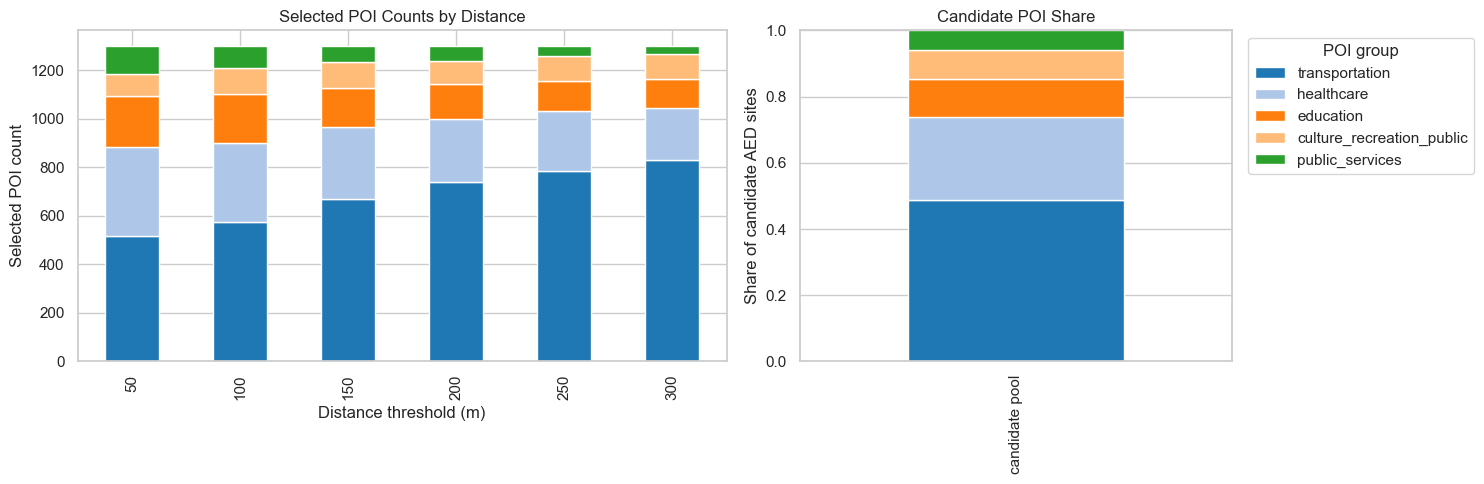

### XGB deployment composition, sample size 5000

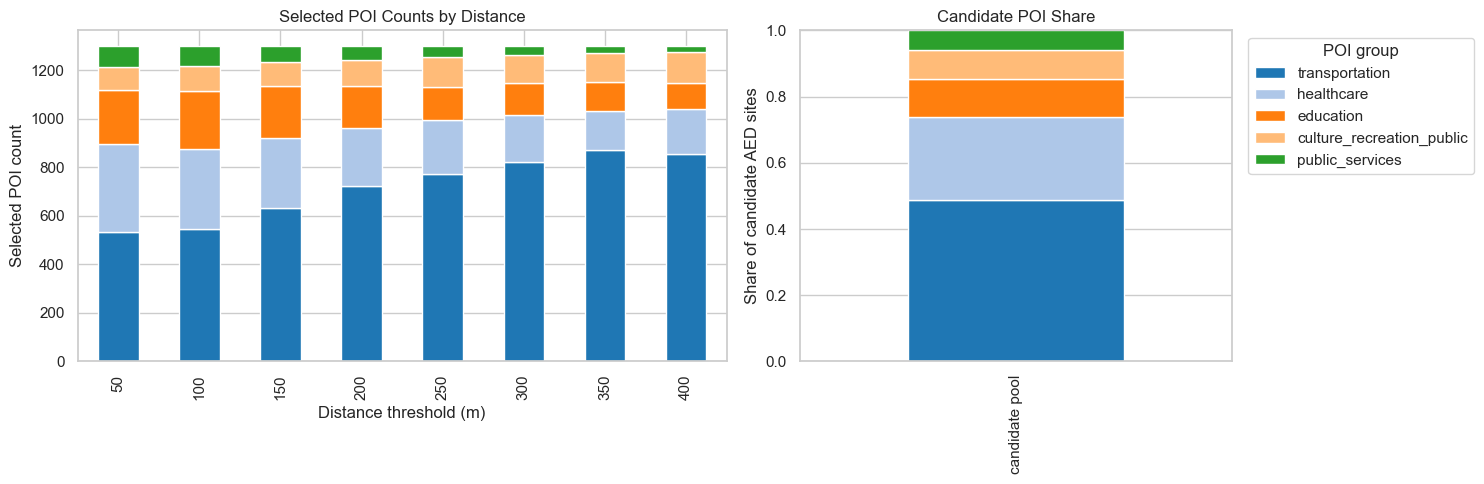

### XGB deployment composition, sample size 6000

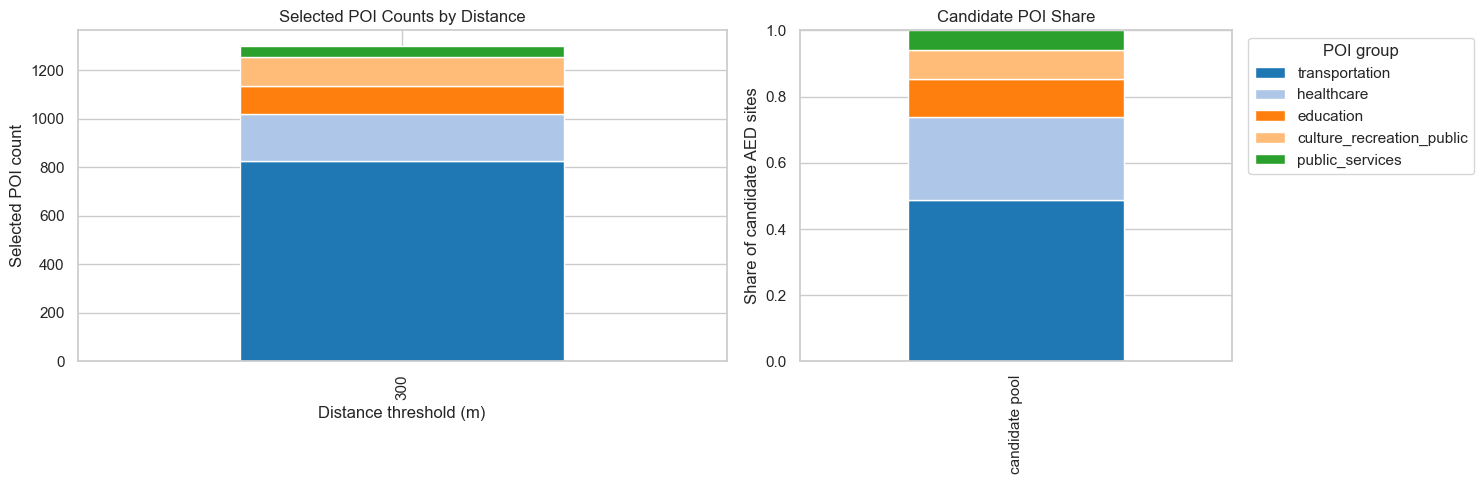

### XGB deployment composition, sample size 7000

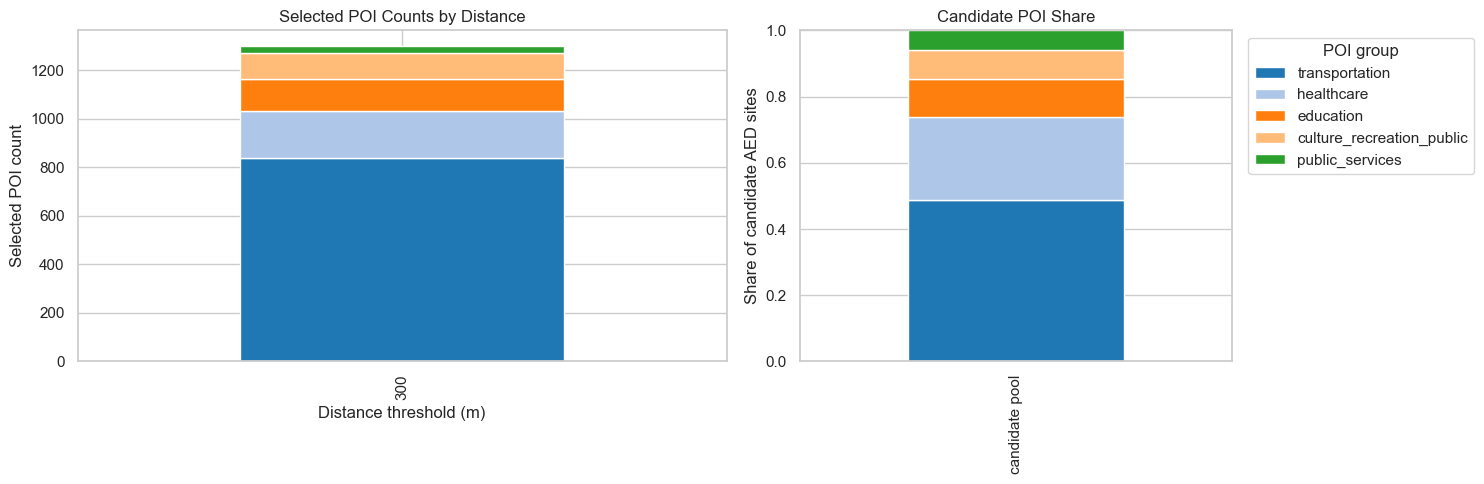

### MLP deployment composition, sample size 3000

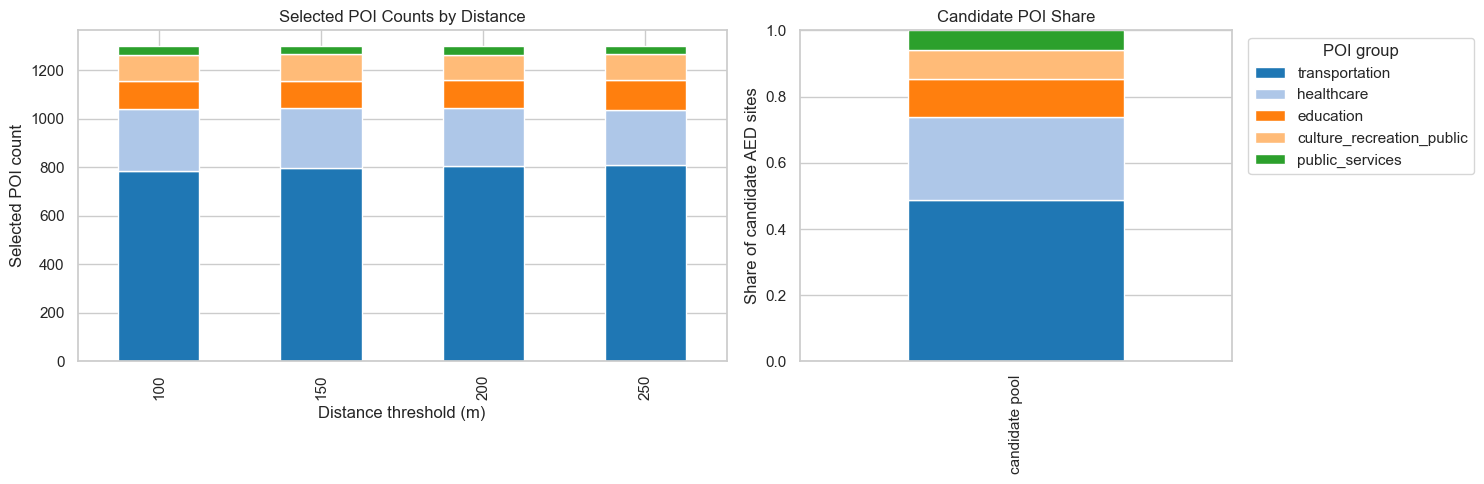

### MLP deployment composition, sample size 4000

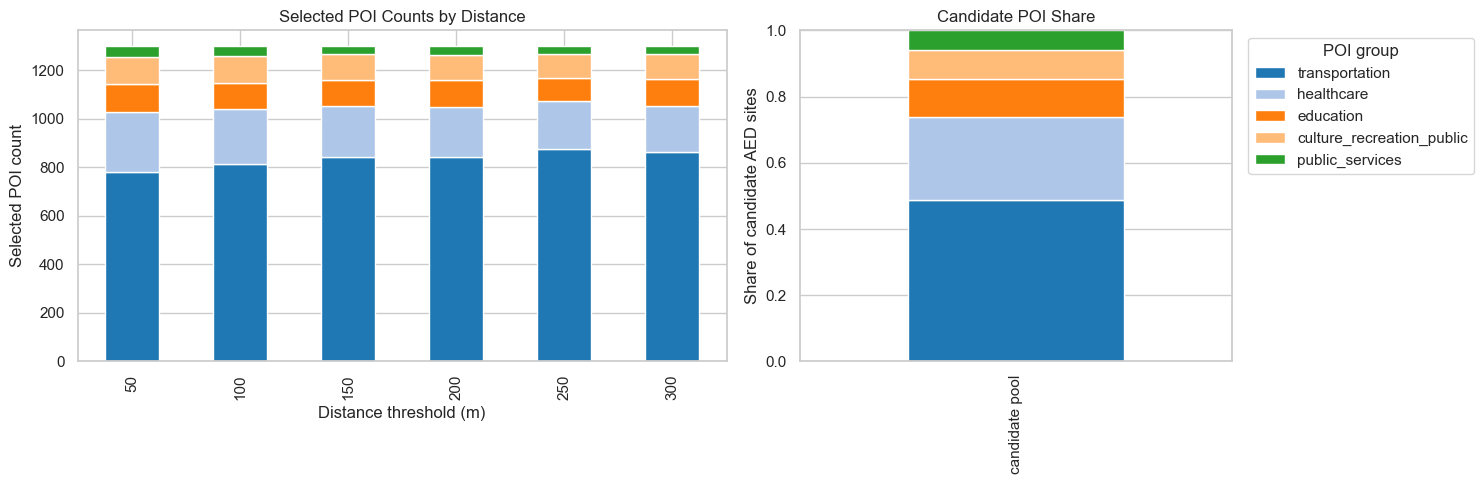

### MLP deployment composition, sample size 5000

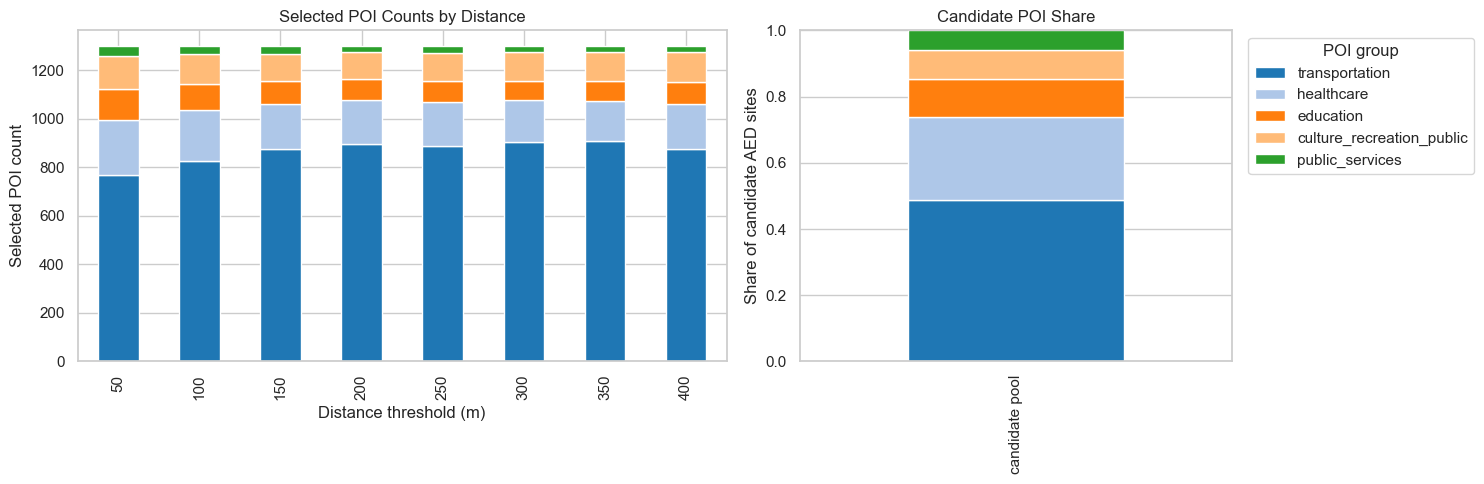

### MLP deployment composition, sample size 6000

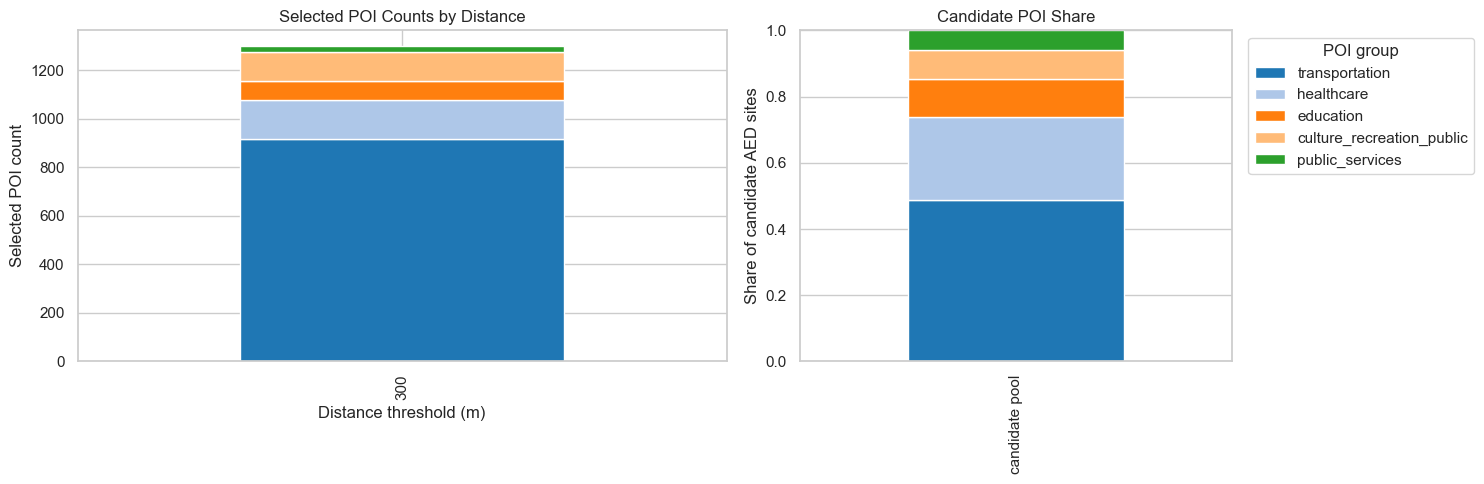

### MLP deployment composition, sample size 7000

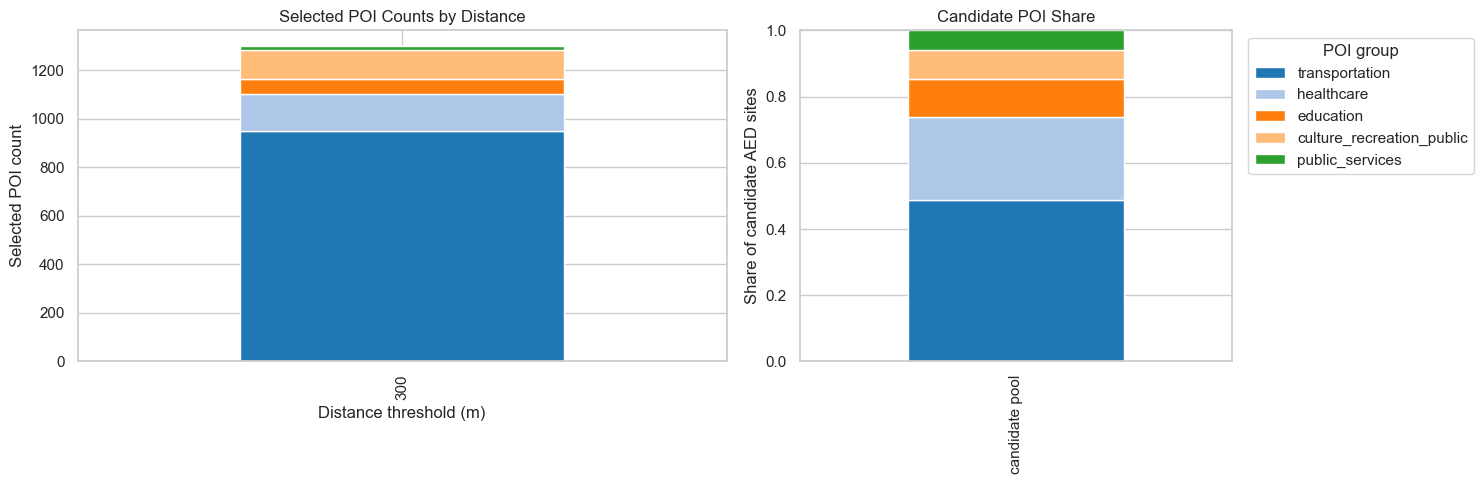

### SVR deployment composition, sample size 3000

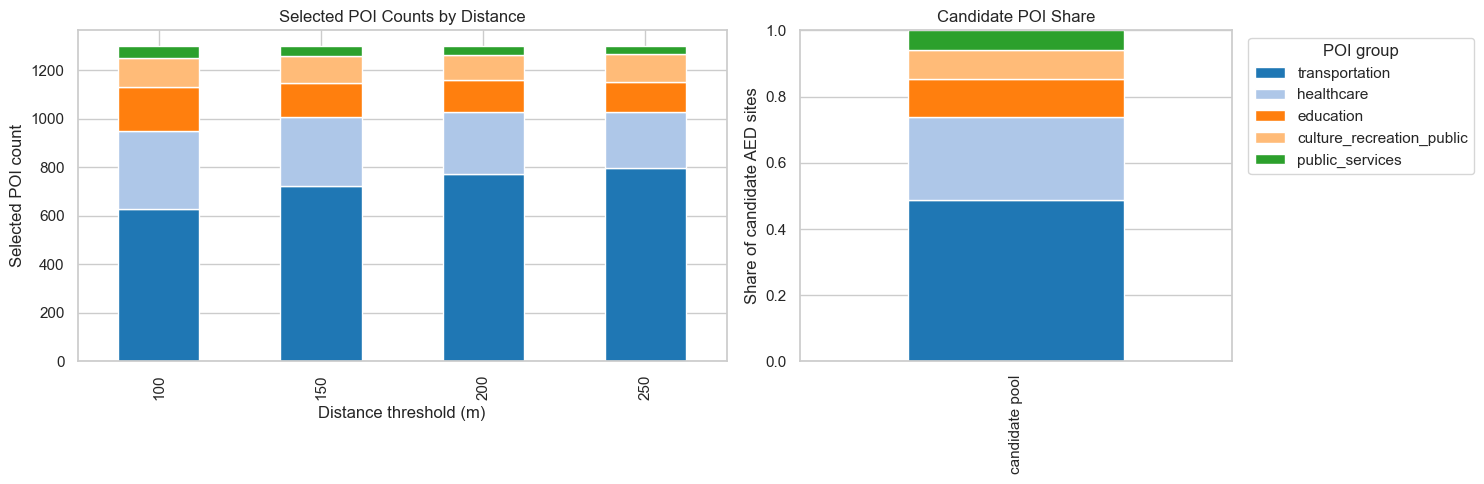

### SVR deployment composition, sample size 4000

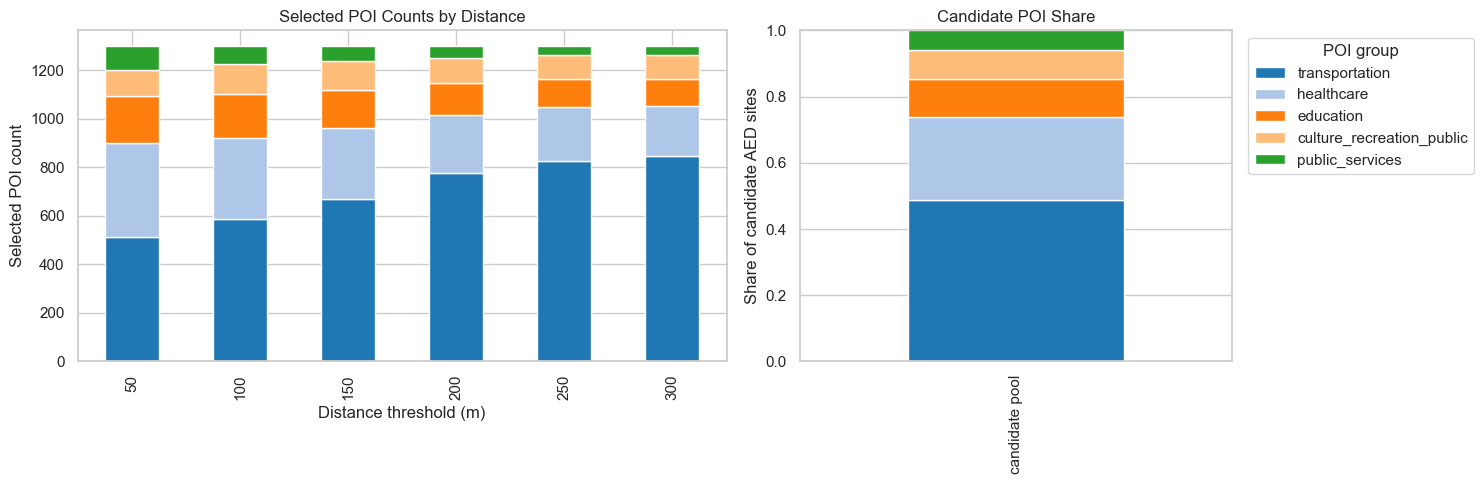

### SVR deployment composition, sample size 5000

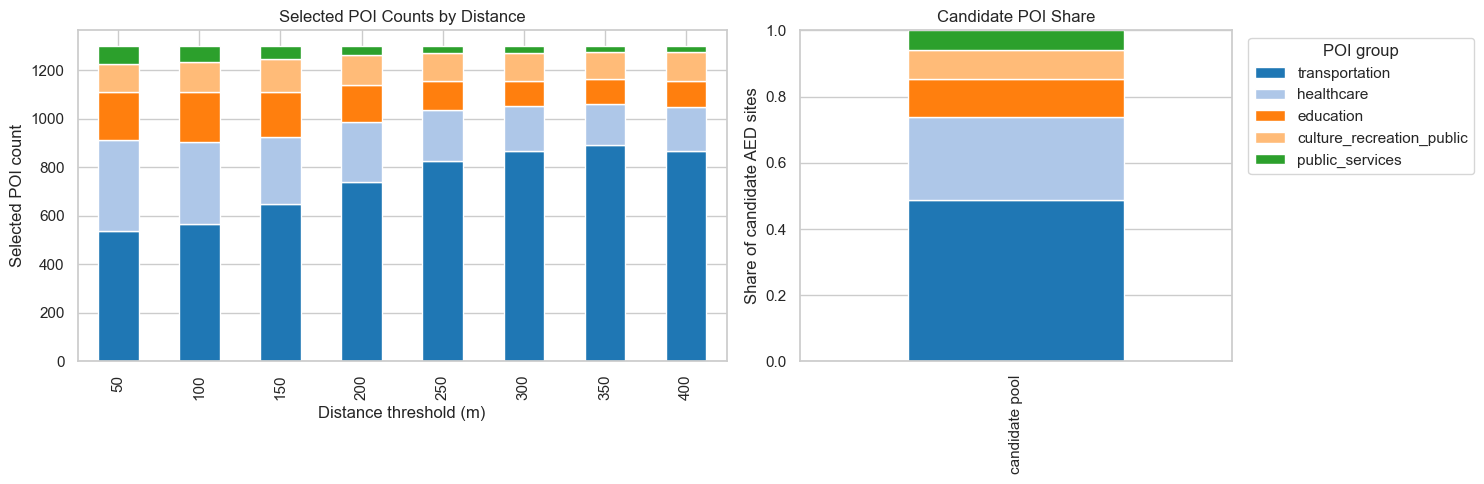

### SVR deployment composition, sample size 6000

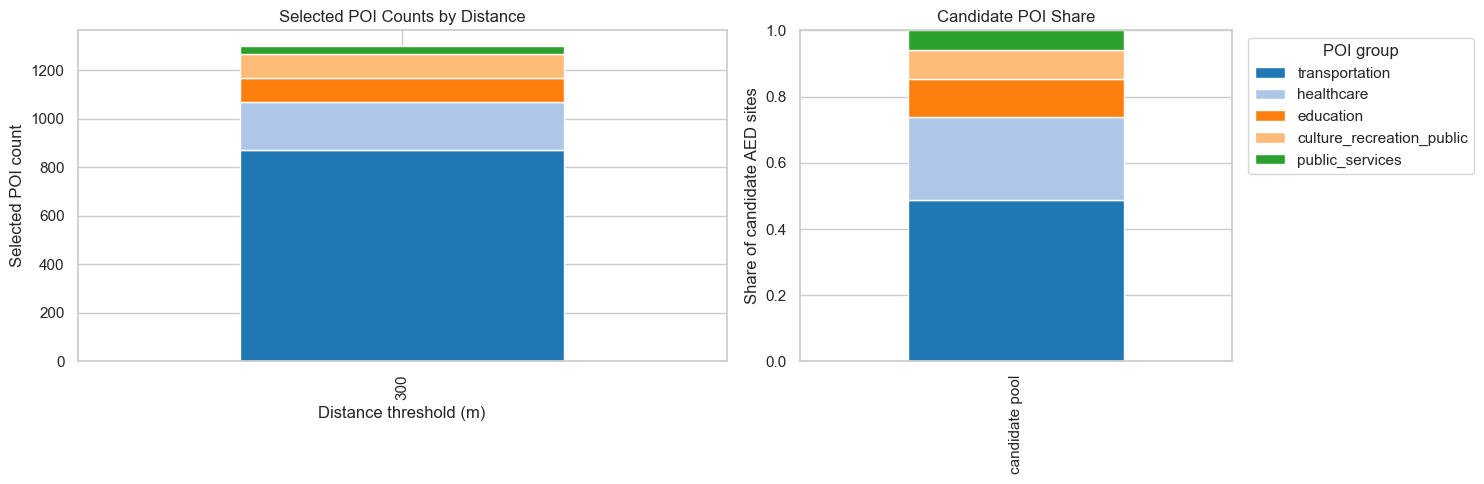

### SVR deployment composition, sample size 7000

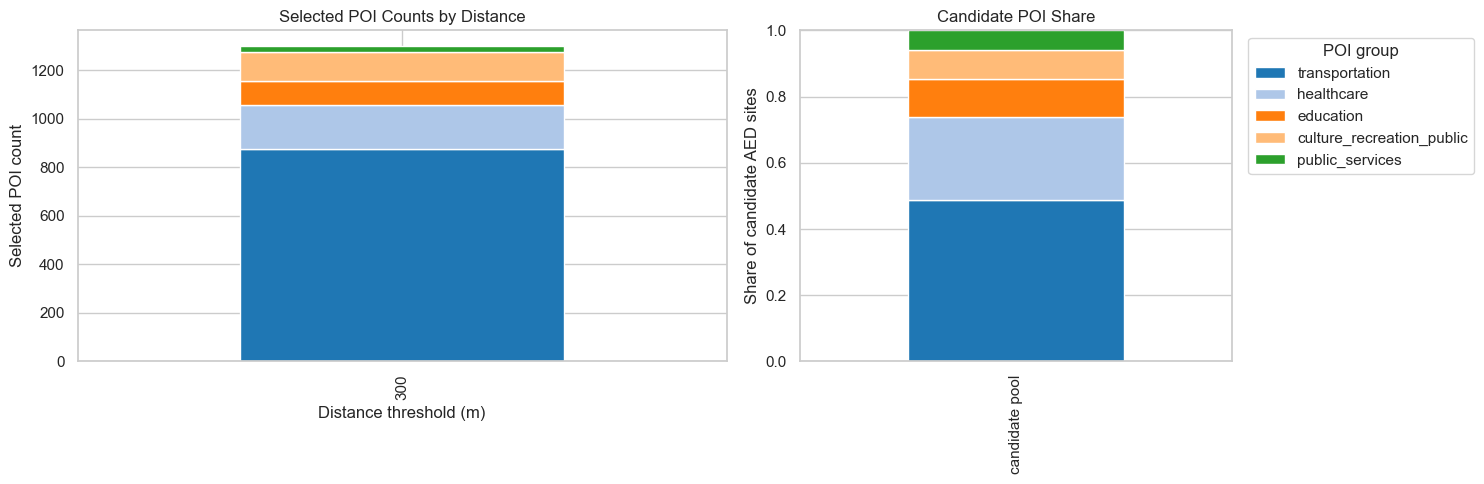

In [16]:
# Visualize how deployment composition changes as distance threshold increases.
SAMPLE_SIZE_FILTER = None  # Example: 3000. Leave as None to show every sample size.

plot_deploy = deployment_group_counts.copy()
if SAMPLE_SIZE_FILTER is not None:
    plot_deploy = plot_deploy[plot_deploy["sample_size"] == SAMPLE_SIZE_FILTER]

poi_group_order = candidate_group_counts["poi_group"].tolist()
extra_groups = sorted(set(plot_deploy["poi_group"]) - set(poi_group_order))
poi_group_order = poi_group_order + extra_groups
color_map = plt.get_cmap("tab20")
poi_group_colors = {group: color_map(i % color_map.N) for i, group in enumerate(poi_group_order)}

candidate_share_pivot = (
    candidate_group_counts.set_index("poi_group")["share"]
    .reindex(poi_group_order, fill_value=0)
    .to_frame()
    .T
)
candidate_share_pivot.index = ["candidate pool"]

for model in MODEL_ORDER:
    model_df = plot_deploy[plot_deploy["model"] == model].copy()
    if model_df.empty:
        continue

    for sample_size, size_df in model_df.groupby("sample_size", sort=True):
        pivot = (
            size_df.pivot_table(index="distance_m", columns="poi_group", values="selected_appearances", aggfunc="sum", fill_value=0)
            .sort_index()
            .reindex(columns=poi_group_order, fill_value=0)
        )
        selected_share_pivot = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
        plot_colors = [poi_group_colors[group] for group in poi_group_order]

        display(Markdown(f"### {MODEL_LABELS[model]} deployment composition, sample size {int(sample_size)}"))
        fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.2, 0.8]})
        selected_share_pivot.plot(kind="bar", stacked=True, ax=axes[0], color=plot_colors)
        axes[0].set_title("Selected POI Share by Distance")
        axes[0].set_xlabel("Distance threshold (m)")
        axes[0].set_ylabel("Share of selected AED sites")
        axes[0].legend_.remove()


        candidate_share_pivot.plot(kind="bar", stacked=True, ax=axes[1], color=plot_colors)
        axes[1].set_title("Candidate POI Share")
        axes[1].set_xlabel("")
        axes[1].set_ylabel("Share of candidate AED sites")
        axes[1].legend(title="POI group", bbox_to_anchor=(1.02, 1), loc="upper left")

        for ax in axes:
            ax.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

## Deployment Enrichment Versus Candidate Availability

Enrichment compares selected share against candidate share. Values above `1.0` mean a POI group is selected more often than its availability in the candidate pool; values below `1.0` mean it is selected less often than availability.

Average deployment enrichment by model and POI group


,model,poi_group,mean_selected_share,mean_candidate_share,mean_enrichment_ratio,max_enrichment_ratio
4,mlp,transportation,0.654923,0.488436,1.340856,1.496140
0,mlp,culture_recreation_public,0.087346,0.087481,0.998457,1.195862
1,mlp,education,0.077577,0.115636,0.670872,0.858130
2,mlp,healthcare,0.156385,0.249623,0.626483,0.785801
3,mlp,public_services,0.023769,0.058824,0.404077,0.601538
9,svr,transportation,0.570500,0.488436,1.168013,1.403222
5,svr,culture_recreation_public,0.087385,0.087481,0.998897,1.187069
6,svr,education,0.109692,0.115636,0.948600,1.390304
7,svr,healthcare,0.197769,0.249623,0.792272,1.192568
8,svr,public_services,0.034654,0.058824,0.589115,1.268462


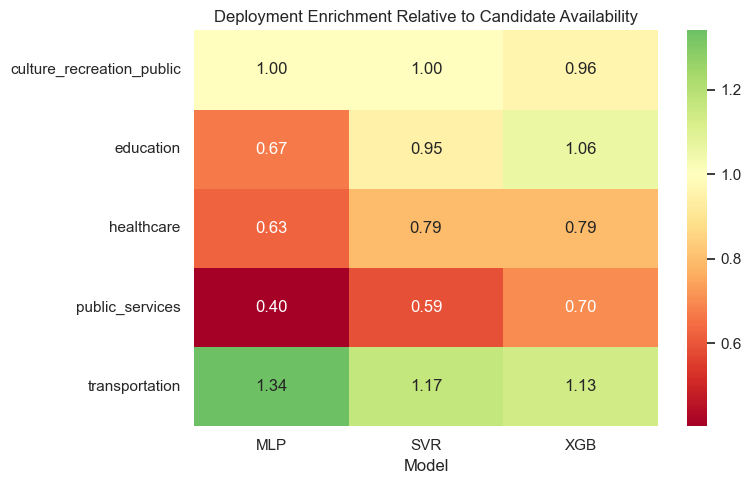

In [17]:
candidate_share = candidate_group_counts[["poi_group", "share"]].rename(columns={"share": "candidate_share"})

enrichment = deployment_group_counts.merge(candidate_share, on="poi_group", how="left")
enrichment["selection_to_candidate_share_ratio"] = enrichment["share_in_run"] / enrichment["candidate_share"]

enrichment_summary = (
    enrichment.groupby(["model", "poi_group"], observed=True)
    .agg(
        mean_selected_share=("share_in_run", "mean"),
        mean_candidate_share=("candidate_share", "mean"),
        mean_enrichment_ratio=("selection_to_candidate_share_ratio", "mean"),
        max_enrichment_ratio=("selection_to_candidate_share_ratio", "max"),
    )
    .reset_index()
)

print("Average deployment enrichment by model and POI group")
display(enrichment_summary.sort_values(["model", "mean_enrichment_ratio"], ascending=[True, False]))

heat = enrichment_summary.pivot(index="poi_group", columns="model", values="mean_enrichment_ratio")
heat = heat.rename(columns=MODEL_LABELS)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0, ax=ax)
ax.set_title("Deployment Enrichment Relative to Candidate Availability")
ax.set_xlabel("Model")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Policy-Oriented Summary Tables

These compact tables combine availability, score priority, deployment share, and enrichment. They are intended as a quick evidence base for deciding which building or public-service categories should be prioritized for AED placement partnerships.

In [18]:
policy_tables = []
for model in MODEL_ORDER:
    score_part = candidate_group_scores[candidate_group_scores["model"] == model][[
        "poi_group",
        "candidate_count",
        "mean_score",
        "top_decile_candidates",
        "top_decile_share_within_group",
    ]]
    deploy_part = enrichment_summary[enrichment_summary["model"] == model][[
        "poi_group",
        "mean_selected_share",
        "mean_candidate_share",
        "mean_enrichment_ratio",
    ]]
    table = score_part.merge(deploy_part, on="poi_group", how="left")
    table["model"] = MODEL_LABELS[model]
    table = table[[
        "model",
        "poi_group",
        "candidate_count",
        "mean_score",
        "top_decile_candidates",
        "top_decile_share_within_group",
        "mean_candidate_share",
        "mean_selected_share",
        "mean_enrichment_ratio",
    ]]
    policy_tables.append(table)

policy_summary = pd.concat(policy_tables, ignore_index=True)
policy_summary = policy_summary.sort_values(["model", "mean_enrichment_ratio", "top_decile_candidates"], ascending=[True, False, False])

display(policy_summary)

for model in MODEL_LABELS.values():
    display(Markdown(f"### {model} policy shortlist"))
    table = policy_summary[policy_summary["model"] == model].copy()
    table = table.sort_values(["mean_enrichment_ratio", "top_decile_candidates", "candidate_count"], ascending=False)
    display(table.head(5))

,model,poi_group,candidate_count,mean_score,top_decile_candidates,top_decile_share_within_group,mean_candidate_share,mean_selected_share,mean_enrichment_ratio
9,MLP,transportation,3886,-5.725054,358,0.092126,0.488436,0.654923,1.340856
5,MLP,culture_recreation_public,696,-7.531934,102,0.146552,0.087481,0.087346,0.998457
6,MLP,education,920,-9.818839,97,0.105435,0.115636,0.077577,0.670872
7,MLP,healthcare,1986,-6.960172,203,0.102216,0.249623,0.156385,0.626483
8,MLP,public_services,468,-10.522924,36,0.076923,0.058824,0.023769,0.404077
14,SVR,transportation,3886,5.118944,283,0.072826,0.488436,0.570500,1.168013
10,SVR,culture_recreation_public,696,5.318579,74,0.106322,0.087481,0.087385,0.998897
11,SVR,education,920,7.479154,107,0.116304,0.115636,0.109692,0.948600
12,SVR,healthcare,1986,10.381726,281,0.141490,0.249623,0.197769,0.792272
13,SVR,public_services,468,6.232041,51,0.108974,0.058824,0.034654,0.589115


### XGB policy shortlist

,model,poi_group,candidate_count,mean_score,top_decile_candidates,top_decile_share_within_group,mean_candidate_share,mean_selected_share,mean_enrichment_ratio
4,XGB,transportation,3886,0.482639,294,0.075656,0.488436,0.553885,1.133995
1,XGB,education,920,0.889339,107,0.116304,0.115636,0.122769,1.061687
0,XGB,culture_recreation_public,696,0.506554,49,0.070402,0.087481,0.083923,0.959328
2,XGB,healthcare,1986,0.850064,292,0.147029,0.249623,0.198115,0.793659
3,XGB,public_services,468,0.902935,54,0.115385,0.058824,0.041308,0.702231


### MLP policy shortlist

,model,poi_group,candidate_count,mean_score,top_decile_candidates,top_decile_share_within_group,mean_candidate_share,mean_selected_share,mean_enrichment_ratio
9,MLP,transportation,3886,-5.725054,358,0.092126,0.488436,0.654923,1.340856
5,MLP,culture_recreation_public,696,-7.531934,102,0.146552,0.087481,0.087346,0.998457
6,MLP,education,920,-9.818839,97,0.105435,0.115636,0.077577,0.670872
7,MLP,healthcare,1986,-6.960172,203,0.102216,0.249623,0.156385,0.626483
8,MLP,public_services,468,-10.522924,36,0.076923,0.058824,0.023769,0.404077


### SVR policy shortlist

,model,poi_group,candidate_count,mean_score,top_decile_candidates,top_decile_share_within_group,mean_candidate_share,mean_selected_share,mean_enrichment_ratio
14,SVR,transportation,3886,5.118944,283,0.072826,0.488436,0.570500,1.168013
10,SVR,culture_recreation_public,696,5.318579,74,0.106322,0.087481,0.087385,0.998897
11,SVR,education,920,7.479154,107,0.116304,0.115636,0.109692,0.948600
12,SVR,healthcare,1986,10.381726,281,0.141490,0.249623,0.197769,0.792272
13,SVR,public_services,468,6.232041,51,0.108974,0.058824,0.034654,0.589115


## Notes for Interpretation

- The score columns are model-derived, SHAP-based candidate scores used by the optimizer, not observed OHCA event counts.
- Deployment counts are based on sample 1 across the available parameter runs. When comparing distance thresholds, use the same model and sample size.
- A strong policy candidate category should usually have three properties: enough available candidate sites, high model score or top-decile presence, and repeated selection in optimized deployment results.